In [16]:
import os
import sys
import numpy as np
import mne
 
EXPECTED_TIMEPOINTS = 641


from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from mne.decoding import CSP
 
# Add src/ to path if not already importable
sys.path.append("/Users/prajwalnara/Documents/EEG-motor-imagery")  # adjust if needed
 
EPOCH_DIR = "/Users/prajwalnara/Documents/EEG-motor-imagery/data/processed/epochs"
CANONICAL_EVENT_ID = {"rest": 1, "left": 2, "right": 3}
N_CSP_COMPONENTS = 4  # per binary CSP; 4 is a common starting point in BCI literature
 
# Subject-count checkpoints to compare. Each checkpoint's subject pool
# is a SUBSET of every larger checkpoint's pool (first N of S001..S109,
# always in the same fixed order) — this keeps "improvement from more
# data" uncontaminated by *which* subjects were added, not just how many.
SUBJECT_CHECKPOINTS = [10, 20, 50, 109]
ALL_SUBJECTS_ORDERED = [f"S{i:03d}" for i in range(1, 110)]  # fixed order, never shuffled
 
TEST_FRACTION = 0.3  # same 70/30 split rule applied at every checkpoint
 
 
def get_split_for_checkpoint(n_subjects):
    """
    Returns (train_subjects, test_subjects) for a given checkpoint size,
    using the first n_subjects of ALL_SUBJECTS_ORDERED, split 70/30.
    Last round(n*TEST_FRACTION) subjects in the slice become test —
    deterministic, not random, so re-running gives identical splits.
    """
    subset = ALL_SUBJECTS_ORDERED[:n_subjects]
    n_test = max(1, round(n_subjects * TEST_FRACTION))
    train_subjects = subset[:-n_test]
    test_subjects = set(subset[-n_test:])
    return train_subjects, test_subjects

In [ ]:
def load_subject_epochs(subject, epoch_dir=EPOCH_DIR):
    """Load and concatenate this subject's R04+R08 (train) and R12 (test)
    epochs, remapping event codes to CANONICAL_EVENT_ID."""
    r04 = mne.read_epochs(
        os.path.join(epoch_dir, subject, f"{subject}R04_epo.fif"),
        preload=True, verbose=False,
    )
    r08 = mne.read_epochs(
        os.path.join(epoch_dir, subject, f"{subject}R08_epo.fif"),
        preload=True, verbose=False,
    )
    r12 = mne.read_epochs(
        os.path.join(epoch_dir, subject, f"{subject}R12_epo.fif"),
        preload=True, verbose=False,
    )
 
    assert r04.event_id == r08.event_id == r12.event_id, (
        f"{subject}: event_id mismatch across runs"
    )
    event_id_map = r04.event_id
    code_to_name = {v: k for k, v in event_id_map.items()}
    remap = {c: CANONICAL_EVENT_ID[name] for c, name in code_to_name.items()}
    
    
    train_epochs = mne.concatenate_epochs([r04, r08])
    test_epochs = r12
 
    # Remap event codes in-place via the events array (3rd column = code)
    train_epochs.events[:, -1] = [remap[c] for c in train_epochs.events[:, -1]]
    test_epochs.events[:, -1] = [remap[c] for c in test_epochs.events[:, -1]]
 
    return train_epochs, test_epochs

In [19]:
def run_csp_lda_experiment(train_subjects, test_subjects, checkpoint_label=""):
    EXPECTED_TIMEPOINTS = 641  # from tmax=4.0 at 160Hz
    all_subjects = list(train_subjects) + list(test_subjects)
 
    # --- Load all subjects, pool with subject_id tracking ---
    X_list, y_list, subj_list = [], [], []
    loaded, skipped = [], []
    
    for subject in all_subjects:
        try:
            train_ep, test_ep = load_subject_epochs(subject)
            X_tr = train_ep.get_data()
            X_te = test_ep.get_data()

            # --- Validation logic to catch shape/timepoints mismatches ---
            if X_tr.shape[-1] != EXPECTED_TIMEPOINTS or X_te.shape[-1] != EXPECTED_TIMEPOINTS:
                raise ValueError(
                    f"unexpected epoch length: train={X_tr.shape[-1]}, "
                    f"test={X_te.shape[-1]}, expected {EXPECTED_TIMEPOINTS}"
                )
 
            y_tr = train_ep.events[:, -1]
            y_te = test_ep.events[:, -1]
 
            X_list.append(np.concatenate([X_tr, X_te], axis=0))
            y_list.append(np.concatenate([y_tr, y_te], axis=0))
            subj_list.append(np.full(len(y_tr) + len(y_te), subject))
            loaded.append(subject)
            
        except Exception as e:
            print(f"  [{checkpoint_label}] Skipping {subject}: {e}")
            skipped.append(subject)
 
    if not X_list:
        print(f"[{checkpoint_label}] Error: No subjects were successfully loaded.")
        return None

    X_all = np.concatenate(X_list, axis=0)
    y_all = np.concatenate(y_list, axis=0)
    subject_ids_all = np.concatenate(subj_list, axis=0)
 
    print(f"[{checkpoint_label}] Loaded {len(loaded)}/{len(all_subjects)} subjects "
          f"(skipped: {skipped})")
 
    # --- Subject-level split ---
    train_mask = np.isin(subject_ids_all, list(train_subjects))
    test_mask = np.isin(subject_ids_all, list(test_subjects))
 
    X_train_raw, y_train = X_all[train_mask], y_all[train_mask]
    X_test_raw, y_test = X_all[test_mask], y_all[test_mask]
 
    print(f"[{checkpoint_label}] Train: {X_train_raw.shape}, "
          f"label counts={dict(zip(*np.unique(y_train, return_counts=True)))}")
    print(f"[{checkpoint_label}] Test:  {X_test_raw.shape}, "
          f"label counts={dict(zip(*np.unique(y_test, return_counts=True)))}")
 
    # --- One-vs-Rest CSP ---
    X_train_csp_parts, X_test_csp_parts = [], []
    for class_name, class_code in CANONICAL_EVENT_ID.items():
        y_train_binary = (y_train == class_code).astype(int)
        csp = CSP(n_components=N_CSP_COMPONENTS, reg=None, log=True, norm_trace=False)
        csp.fit(X_train_raw, y_train_binary)
        X_train_csp_parts.append(csp.transform(X_train_raw))
        X_test_csp_parts.append(csp.transform(X_test_raw))
 
    X_train_csp = np.concatenate(X_train_csp_parts, axis=1)
    X_test_csp = np.concatenate(X_test_csp_parts, axis=1)
 
    # --- Scale + LDA ---
    scaler = StandardScaler()
    X_train_csp_scaled = scaler.fit_transform(X_train_csp)
    X_test_csp_scaled = scaler.transform(X_test_csp)
 
    model = LinearDiscriminantAnalysis()
    model.fit(X_train_csp_scaled, y_train)
    y_pred = model.predict(X_test_csp_scaled)
 
    # --- Evaluate ---
    code_to_name = {v: k for k, v in CANONICAL_EVENT_ID.items()}
    labels_sorted = sorted(CANONICAL_EVENT_ID.values())
    label_names = [code_to_name[c] for c in labels_sorted]
 
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)
    report = classification_report(
        y_test, y_pred, labels=labels_sorted, target_names=label_names, output_dict=True
    )
 
    print(f"[{checkpoint_label}] ACCURACY: {acc:.4f}")
    print(confusion_matrix(y_test, y_pred, labels=labels_sorted))
 
    return {
        "checkpoint": checkpoint_label,
        "n_subjects": len(all_subjects),
        "n_train_subjects": len(train_subjects),
        "n_test_subjects": len(test_subjects),
        "accuracy": acc,
        "confusion_matrix": cm,
        "classification_report": report,
        "n_train_epochs": X_train_raw.shape[0],
        "n_test_epochs": X_test_raw.shape[0],
    }

In [20]:
results = []
 
for n in SUBJECT_CHECKPOINTS:
    train_subjects, test_subjects = get_split_for_checkpoint(n)
    label = f"n={n}"
    print(f"\n{'='*60}\nCheckpoint {label}: "
          f"{len(train_subjects)} train subjects, {len(test_subjects)} test subjects\n{'='*60}")
 
    result = run_csp_lda_experiment(train_subjects, test_subjects, checkpoint_label=label)
    results.append(result)


Checkpoint n=10: 7 train subjects, 3 test subjects
Not setting metadata
60 matching events found
No baseline correction applied


/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_21493/1401341432.py:24: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  train_epochs = mne.concatenate_epochs([r04, r08])


Not setting metadata
60 matching events found
No baseline correction applied
Not setting metadata
60 matching events found
No baseline correction applied
Not setting metadata
60 matching events found
No baseline correction applied


/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_21493/1401341432.py:24: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  train_epochs = mne.concatenate_epochs([r04, r08])
/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_21493/1401341432.py:24: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  train_epochs = mne.concatenate_epochs([r04, r08])
/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_21493/1401341432.py:24: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  train_epochs = mne.concatenate_epochs([r04, r08])


Not setting metadata
60 matching events found
No baseline correction applied


...

Not setting metadata
60 matching events found
No baseline correction applied
Not setting metadata
60 matching events found
No baseline correction applied
Not setting metadata
60 matching events found
No baseline correction applied


/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_21493/1401341432.py:24: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  train_epochs = mne.concatenate_epochs([r04, r08])
/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_21493/1401341432.py:24: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  train_epochs = mne.concatenate_epochs([r04, r08])
/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_21493/1401341432.py:24: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  train_epochs = mne.concatenate_epochs([r04, r08])


Not setting metadata
76 matching events found
No baseline correction applied
  [n=109] Skipping S088: unexpected epoch length: train=513, test=513, expected 641


/var/folders/2p/pvb41hns2szdm00nww51m7r40000gn/T/ipykernel_21493/1401341432.py:24: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  train_epochs = mne.concatenate_epochs([r04, r08])


[n=109] Loaded 106/109 subjects (skipped: ['S092', 'S100', 'S088'])
[n=109] Train: (6825, 64, 641), label counts={np.int32(1): np.int64(3415), np.int32(2): np.int64(1723), np.int32(3): np.int64(1687)}
[n=109] Test:  (2660, 64, 641), label counts={np.int32(1): np.int64(1332), np.int32(2): np.int64(667), np.int32(3): np.int64(661)}
Computing rank from data with rank=None
    Using tolerance 0.0055 (2.2e-16 eps * 64 dim * 3.9e+11  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.0055 (2.2e-16 eps * 64 dim * 3.9e+11  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating c



========== CHECKPOINT COMPARISON ==========
Checkpoint  #Subjects   Train Epochs   Test Epochs    Accuracy  
n=10        10          630            270            0.4741
n=20        20          1260           540            0.4796
n=50        50          3148           1347           0.4707
n=109       109         6825           2660           0.4996


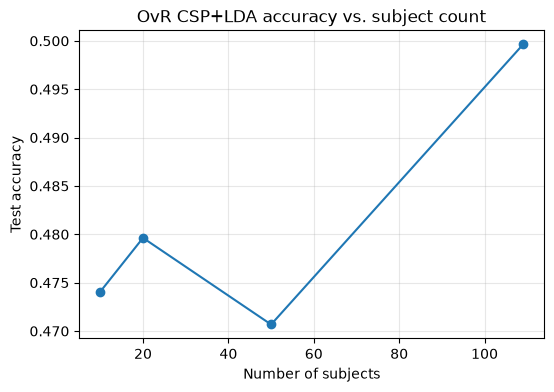

In [21]:
print("\n\n========== CHECKPOINT COMPARISON ==========")
print(f"{'Checkpoint':<12}{'#Subjects':<12}{'Train Epochs':<15}{'Test Epochs':<15}{'Accuracy':<10}")
for r in results:
    print(f"{r['checkpoint']:<12}{r['n_subjects']:<12}{r['n_train_epochs']:<15}"
          f"{r['n_test_epochs']:<15}{r['accuracy']:.4f}")
 
# Optional: quick plot if matplotlib is available
import matplotlib.pyplot as plt
 
ns = [r["n_subjects"] for r in results]
accs = [r["accuracy"] for r in results]
plt.figure(figsize=(6, 4))
plt.plot(ns, accs, marker="o")
plt.xlabel("Number of subjects")
plt.ylabel("Test accuracy")
plt.title("OvR CSP+LDA accuracy vs. subject count")
plt.grid(True, alpha=0.3)
plt.savefig("/Users/prajwalnara/Documents/EEG-motor-imagery/results/figures/csp_lda_subject_scaling.png", dpi=150)
plt.show()